In [1]:
import torch

# Limit to fraction of total GPU memory
torch.cuda.set_per_process_memory_fraction(0.5, device=0)

## Sanity checks

In [2]:
import pandas as pd
lbl_fn = "/home/elek/sds/sd17d003/Anamaria/splicevo/data/processed_full_50kb/human_GRCh37/labels.parquet"
lbl = pd.read_parquet(lbl_fn)
lbl

,sample_idx,position,strand,label
0,0,20233,+,1
1,0,22206,+,2
2,0,22246,+,1
3,0,29766,+,2
4,1,2388,-,2
...,...,...,...,...
599384,55580,26971,-,1
599385,55580,27094,-,2
599386,55580,31756,-,1
599387,55580,31899,-,2


<Axes: >

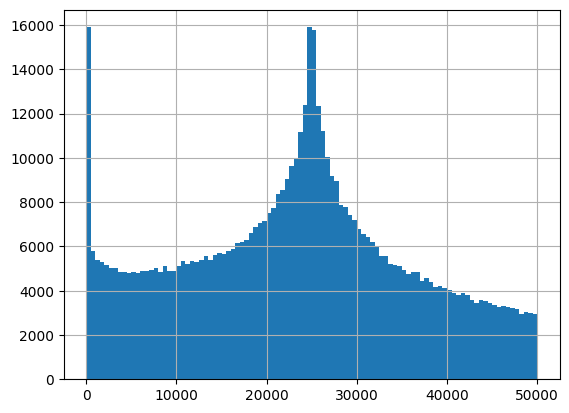

In [3]:
lbl['position'].hist(bins=100)

In [4]:
csv_fn = "/home/elek/sds/sd17d003/Anamaria/splicevo/data/processed_small/human_GRCh37/metadata.csv"
csv = pd.read_csv(csv_fn)
csv

,genome_id,chromosome,gene_id,strand,gene_start,gene_end,gene_length,sequence_start,sequence_end,sequence_length,context_size,n_donor_sites,n_acceptor_sites
0,human_GRCh37,11,hum.10000,-,18424561,18426995,2435,18423561,18427995,4435,1000,2,2
1,human_GRCh37,11,hum.10002,+,18433956,18472509,38554,18432956,18473509,40554,1000,8,7
2,human_GRCh37,11,hum.10007,-,18134835,18139242,4408,18133835,18140242,6408,1000,1,1
3,human_GRCh37,11,hum.10011,+,18230741,18234627,3887,18229741,18235627,5887,1000,3,2
4,human_GRCh37,11,hum.10012,+,18271664,18291263,19600,18270664,18292263,21600,1000,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5711,human_GRCh37,11,hum.9993,-,18078363,18127453,49091,18077363,18128453,51091,1000,14,18
5712,human_GRCh37,11,hum.9996,+,17498279,17513566,15288,17497279,17514566,17288,1000,2,1
5713,human_GRCh37,11,hum.9998,-,18416856,18417668,813,18415856,18418668,2813,1000,1,1
5714,human_GRCh37,11,hum.9999,+,18416184,18428663,12480,18415184,18429663,14480,1000,9,7


In [5]:
i = 0
lbl[lbl['sample_idx']==i]['position'] + csv.loc[i, 'gene_start']

0    18424561
1    18425240
2    18425359
3    18426995
Name: position, dtype: int32

## Make predictions

### Load data for prediction

In [6]:
# Path to test data
test_data_dir = '/home/elek/sds/sd17d003/Anamaria/splicevo/data/splits_small/mouse_human/test/'

import os
import pandas as pd

# First load metadata
meta_csv_fn = os.path.join(test_data_dir, 'metadata.csv')
metadata_csv = pd.read_csv(meta_csv_fn)
print(metadata_csv.head())

import json

meta_fn = os.path.join(test_data_dir, 'metadata.json')
with open(meta_fn) as f:
    metadata = json.load(f)

print("\nWindow size", metadata.get('window_size', None))
print("Context size", metadata.get('context_size', None))
species_conds = metadata.get('species_condition_mapping')

for org, cond in species_conds.items():
    print(f"Conditions for {org}:")
    print([metadata['usage_conditions'][cond_idx] for cond_idx in cond])

      genome_id  chromosome    gene_id strand  gene_start  gene_end  \
0  human_GRCh37          22  hum.42245      -    37196963  37215474   
1  human_GRCh37          22  hum.42257      -    37142411  37172074   
2  human_GRCh37          22  hum.42293      -    37387318  37403769   
3  human_GRCh37          22  hum.42299      +    37309720  37333418   
4  human_GRCh37          22  hum.42312      -    37622080  37640329   

   gene_length  sequence_start  sequence_end  sequence_length  context_size  \
0        18512        37195963      37216474            20512          1000   
1        29664        37141411      37173074            31664          1000   
2        16452        37386318      37404769            18452          1000   
3        23699        37308720      37334418            25699          1000   
4        18250        37621080      37641329            20250          1000   

   n_donor_sites  n_acceptor_sites  species_id  
0              6                 4           0  


In [7]:
%reload_ext autoreload
%autoreload 2
from alphagenome_pytorch import SpliceDataset

# Target length (must be divisible by 2048, e.g. 10kb = 10240, 32kb = 32768, 50kb = 49152, 100kb = 98304)
target_length = 98304
print(f"Target sequence length: {target_length}")

# Calculate max donor/acceptor sites for junctions
max_donor = metadata_csv['n_donor_sites'].max()
max_acceptor = metadata_csv['n_acceptor_sites'].max()
max_sites = max(max_donor, max_acceptor)
max_sites = (max_sites // 10) * 10 
print(f"Max sites: {max_sites}")
max_donor_sites = max_sites
max_acceptor_sites = max_sites

# Species
species_mapping = {
    'human': 0,
    'mouse': 1
}

test_dataset = SpliceDataset(
    data_dir=test_data_dir,
    target_length=target_length,
    max_donor_sites=max_donor_sites,
    max_acceptor_sites=max_acceptor_sites,
    species_mapping=species_mapping
)

2026-03-09 23:03:45.000612: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 23:03:45.041021: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Target sequence length: 98304
Max sites: 80
Loaded dataset from /home/elek/sds/sd17d003/Anamaria/splicevo/data/splits_small/mouse_human/test/


In [9]:
next(iter(test_dataset))

{'dna': tensor([ 1,  0,  3,  ..., -1, -1, -1]),
 'organism_index': tensor(0),
 'splice_donor_idx': tensor([13726, 15183, 17025, 17436, 17587, 19511, 19511, 19511, 19511, 19511,
         19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511,
         19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511,
         19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511,
         19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511,
         19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511,
         19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511,
         19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511, 19511]),
 'splice_acceptor_idx': tensor([  998, 13835, 15315, 17092, 17092, 17092, 17092, 17092, 17092, 17092,
         17092, 17092, 17092, 17092, 17092, 17092, 17092, 17092, 17092, 17092,
         17092, 17092, 17092, 17092, 17092, 17092, 17092, 17092, 17092, 17092,
        

### Check that the inputs are correctly encoded

The genomic coordinates of the first sequence in the test set.

In [10]:
import os
import pandas as pd
meta_csv_fn = os.path.join(test_data_dir, "metadata.csv")
meta_csv = pd.read_csv(meta_csv_fn)

i=5
print(meta_csv.loc[i])
chr = str(meta_csv.loc[i, 'chromosome'])
if "window_with_context_start" in meta_csv.columns:
    start = int(meta_csv.loc[i, 'window_with_context_start'])
    end = int(meta_csv.loc[i, 'window_with_context_end'])
    window_start = int(meta_csv.loc[i, 'window_start'])
    window_end = int(meta_csv.loc[i, 'window_end'])
    gene_start = int(meta_csv.loc[i, 'central_gene_start'])
    gene_end = int(meta_csv.loc[i, 'central_gene_end'])
elif "sequence_start" in meta_csv.columns:
    start = int(meta_csv.loc[i, 'sequence_start'])
    end = int(meta_csv.loc[i, 'sequence_end'])
    gene_start = int(meta_csv.loc[i, 'gene_start'])
    gene_end = int(meta_csv.loc[i, 'gene_end'])
    window_start = gene_start
    window_end = gene_end
strand = str(meta_csv.loc[i, 'strand'])
gene = str(meta_csv.loc[i, 'gene_id'])

genome_id           human_GRCh37
chromosome                    22
gene_id                hum.42329
strand                         -
gene_start              37865351
gene_end                37915349
gene_length                49999
sequence_start          37864351
sequence_end            37916349
sequence_length            51999
context_size                1000
n_donor_sites                 32
n_acceptor_sites              30
species_id                     0
Name: 5, dtype: object


In [11]:
print("Window with context")
print(f"{chr}:{start}-{end} ({strand}), gene: {gene}")
print("Window without context")
print(f"{chr}:{window_start}-{window_end} ({strand}), gene: {gene}")
print("Gene region")
print(f"{chr}:{gene_start}-{gene_end} ({strand}), gene: {gene}")

Window with context
22:37864351-37916349 (-), gene: hum.42329
Window without context
22:37865351-37915349 (-), gene: hum.42329
Gene region
22:37865351-37915349 (-), gene: hum.42329


In [12]:
dna_window = test_dataset[i]['dna']
dna_len = len(dna_window)
if "sequences_shape" in metadata:
    offset = (metadata['sequences_shape'][1] - dna_len) // 2
else:
    offset = 0
print(f"DNA length: {dna_len}, offset: {offset}\n")

print("Window with context (adjusted for offset)")
print(f"{chr}:{start+offset+1}-{end+offset} ({strand}), gene: {gene}")

DNA length: 98304, offset: 0

Window with context (adjusted for offset)
22:37864352-37916349 (-), gene: hum.42329


Extracting the corresponding fasta and gtf records for this region.

```bash
# Sort and index if needed
zcat /home/elek/sds/sd17d003/Anamaria/genomes/mazin/gtf/Homo_sapiens.gtf.gz \
  | sort -k1,1 -k4,4n \
  | bgzip > /home/elek/sds/sd17d003/Anamaria/genomes/mazin/gtf/Homo_sapiens.sorted.gtf.gz
tabix -p gff /home/elek/sds/sd17d003/Anamaria/genomes/mazin/gtf/Homo_sapiens.sorted.gtf.gz

# Files to check against
gtf_fn=/home/elek/sds/sd17d003/Anamaria/genomes/mazin/gtf/Homo_sapiens.sorted.gtf.gz
fasta_fn="/home/elek/sds/sd17d003/Anamaria/genomes/mazin/fasta/Homo_sapiens.fa.gz"

# Coordinates to check (Window with context adjusted for offset from above)
coord="22:37864352-37916349"
gene="hum.42329"

# Extract fasta sequence
samtools faidx $fasta_fn $coord > region.fa

# Extract gtf records
tabix $gtf_fn $coord > region.gtf

# Check that the extracted fasta region corresponds to the ohe DNA in the dataset
head region.fa -n 2

# Check that enncoded splice sites correspond to exon start/ends - 1
less region.gtf | grep $gene | grep "exon"
```

Check that DNA sequence is correct

In [13]:
def ohe(dna_ohe):
    """[0, 1, 2, 3] -> [A, C, G, T]"""
    return ''.join(['ACGT'[i] for i in dna_ohe])
def rev(dna_seq):
    """Complement of a DNA sequence"""
    complement = str.maketrans('ACGT', 'TGCA')
    return dna_seq.translate(complement)

print(dna_window[0:60])
dna_seq = ohe(dna_window[0:60])
print(dna_seq)
if strand == '-':
    print(rev(dna_seq))

tensor([2, 0, 2, 3, 1, 3, 1, 1, 0, 3, 3, 1, 1, 2, 1, 1, 3, 3, 1, 1, 1, 3, 2, 0,
        3, 3, 1, 3, 1, 3, 2, 0, 1, 1, 3, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 2, 2,
        1, 1, 1, 3, 2, 2, 2, 2, 2, 1, 0, 2])
GAGTCTCCATTCCGCCTTCCCTGATTCTCTGACCTCCCCCAACCCAGGCCCTGGGGGCAG
CTCAGAGGTAAGGCGGAAGGGACTAAGAGACTGGAGGGGGTTGGGTCCGGGACCCCCGTC


Check that the splice sites indices are correct

In [14]:
print("Central window region:")
coord = f"{chr}:{window_start+offset+1}-{window_end+offset}"
print(coord, strand, gene, "\n")

splice_sites = test_dataset[i]['splice_labels']

splice_donor_idx = test_dataset[i]['splice_donor_idx'].unique().numpy()
splice_acceptor_idx = test_dataset[i]['splice_acceptor_idx'].unique().numpy()

splice_donor_encode = splice_sites[splice_donor_idx].numpy()
splice_acceptor_encode = splice_sites[splice_acceptor_idx].numpy()

splice_donor_count = len(splice_sites[splice_sites == splice_donor_encode[0]])
splice_acceptor_count = len(splice_sites[splice_sites == splice_acceptor_encode[0]])

# Check that encoding at splice sites corresponds to idx 
print(f"There are {splice_donor_count} donor sites in this sequence:")
print(f"{splice_donor_idx}")
print(f"Genomic coordinates: {[int(start + offset + idx) for idx in splice_donor_idx]}")
print(f"Donors on {strand} strand encoded as: {splice_donor_encode}")


print(f"\nThere are {splice_acceptor_count} acceptor sites in this sequence.")
print(f"{splice_acceptor_idx}")
print(f"Genomic coordinates: {[int(start + offset + idx) for idx in splice_acceptor_idx]}")
print(f"Acceptors on {strand} strand encoded as: {splice_acceptor_encode}")

Central window region:
22:37865352-37915349 - hum.42329 

There are 32 donor sites in this sequence:
[ 1628  4129  6198  8582 11031 11883 12407 17602 17609 17634 21536 23410
 24090 24299 25741 27172 27415 28104 28674 34257 34840 35841 36290 37847
 39484 39999 40182 41867 47628 49626 50621 50998]
Genomic coordinates: [37865979, 37868480, 37870549, 37872933, 37875382, 37876234, 37876758, 37881953, 37881960, 37881985, 37885887, 37887761, 37888441, 37888650, 37890092, 37891523, 37891766, 37892455, 37893025, 37898608, 37899191, 37900192, 37900641, 37902198, 37903835, 37904350, 37904533, 37906218, 37911979, 37913977, 37914972, 37915349]
Donors on - strand encoded as: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

There are 30 acceptor sites in this sequence.
[  998  1715  4214  6363  8667 11184 11985 12455 17685 23079 23522 24205
 24457 25843 27241 27658 28215 28833 34380 34868 35956 36424 38038 39609
 40054 40337 42076 47953 49763 50872]
Genomic coordinates: [37865349, 3

### Subset _n_ sequences

First _n_ sequences from the test set.

In [ ]:
import torch
import numpy as np

np.random.seed(1901)

n_per_species = 8
n = n_per_species * len(species_mapping)
rand_indx = []
for species in species_mapping.keys():
    species_id = metadata['species_mapping'][species]
    species_idx = metadata_csv[metadata_csv['species_id'] == species_id].index.tolist()
    print(f"{len(species_idx)} samples available for {species}")
    rand_indx.extend(np.random.choice(species_idx, n_per_species, replace=False))

organism_index = []
for i in rand_indx:
    organism_index.append(test_dataset[i]['organism_index'])

organism_index = torch.tensor(organism_index)
print(organism_index.shape)
organism_index

Organism that the first _n_ sequences belong to.

In [ ]:
dna = []
for i in rand_indx:
    dna.append(test_dataset[i]['dna'])
dna = torch.stack(dna)
print(dna.shape)
dna

Splice labels

In [ ]:
splice_labels = []
for i in rand_indx:
    splice_labels.append(test_dataset[i]['splice_labels'])
splice_labels = torch.stack(splice_labels)
print(splice_labels.shape)
print(splice_labels)

# Count splice sites in the batch
for i in range(splice_labels.shape[0]):
    donor_plus_count = (splice_labels[i] == 0).sum().item()
    acceptor_plus_count = (splice_labels[i] == 1).sum().item()
    donor_minus_count = (splice_labels[i] == 2).sum().item()
    acceptor_minus_count = (splice_labels[i] == 3).sum().item()
    print(f"Sample {i}: ")
    print(f"  {donor_plus_count} donor sites: {(splice_labels[i] == 0).nonzero(as_tuple=True)[0].numpy()}")
    print(f"  {acceptor_plus_count} acceptor sites: {(splice_labels[i] == 1).nonzero(as_tuple=True)[0].numpy()}")
    print(f"  {donor_minus_count} donor minus sites: {(splice_labels[i] == 2).nonzero(as_tuple=True)[0].numpy()}")
    print(f"  {acceptor_minus_count} acceptor minus sites: {(splice_labels[i] == 3).nonzero(as_tuple=True)[0].numpy()}")

Splice usage

In [ ]:
splice_usage = []
for i in rand_indx:
    splice_usage.append(test_dataset[i]['splice_usage_target'])
splice_usage = torch.stack(splice_usage)
print(splice_usage.shape)
splice_usage

In [ ]:
# Histogram of splice_usage where splice_usage > 0
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.hist(splice_usage[splice_usage > 0].numpy().flatten(), bins=50)
plt.title("Distribution of Splice Usage (where splice_usage > 0)")
plt.xlabel("Splice Usage")
plt.ylabel("Frequency")
plt.show()

Gene region to restrict splice predictions to

In [ ]:
gene_region = []
for i in rand_indx:
    gene_region.append(test_dataset[i]['gene_region'])
gene_region

### Load pretrained model

In [ ]:
import torch
from alphagenome_pytorch import AlphaGenome
from pathlib import Path

def load_pretrained_model(cache_dir='../outputs/checkpoints/pretrained', num_organisms=2):
    """
    Load the pretrained AlphaGenome model with caching.
    
    First time: Downloads and converts JAX model (~5 minutes) and caches it
    Subsequent times: Loads from cache (under 1 minute)
    
    Args:
        cache_dir: Directory to store cached model
        num_organisms: Number of organisms (default: 2 for human and mouse)
    
    Returns:
        model: AlphaGenome model in eval mode
    """
    # Path to cache the converted model
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(exist_ok=True, parents=True)
    cached_model_path = cache_dir / 'pretrained_model_all_folds.pt'
    
    model = AlphaGenome(num_organisms=num_organisms)
    model.add_reference_heads("human")
    model.add_reference_heads('mouse')
    
    # Load from cache if available, otherwise download and cache
    if cached_model_path.exists():
        print(f"Loading pretrained model from cache: {cached_model_path}")
        checkpoint = torch.load(cached_model_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        print("Model loaded from cache (fast!)")
    else:
        print("Downloading and converting JAX model (this will take ~5 minutes)...")
        model.load_from_official_jax_model("all_folds")
        print("Saving to cache for future use...")
        torch.save({'model_state_dict': model.state_dict()}, cached_model_path)
        print(f"Model cached to {cached_model_path}")
    
    model.eval()
    return model

In [ ]:
use_pretrained_model = True

if use_pretrained_model:
    model = load_pretrained_model()

### Load fine-tuned model

In [ ]:
import os
import yaml
import torch
from alphagenome_pytorch import AlphaGenome, AlphaGenomeConfig

use_finetuned_model = True

if use_finetuned_model:

    # Load config
    config_file = '../configs/splice_finetune_full_50kb.yaml'
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)

    # Get model architecture parameters (matching training)
    default_cfg = AlphaGenomeConfig()
    model_cfg = config.get('model', {})
    dims = tuple(model_cfg.get('dims', default_cfg.dims))
    basepairs = model_cfg.get('basepairs', default_cfg.basepairs)
    dna_embed_width = model_cfg.get('dna_embed_width', default_cfg.dna_embed_width)
    num_organisms = model_cfg.get('num_organisms', default_cfg.num_organisms)
    transformer_kwargs = model_cfg.get('transformer_kwargs', default_cfg.transformer_kwargs)
    heads_cfg = model_cfg.get('heads_cfg')

    # Create model with same architecture as training
    model = AlphaGenome(dims, basepairs, dna_embed_width, num_organisms, transformer_kwargs)

    # Add heads with same config as training
    for organism, head_cfg in heads_cfg.items():
        model.add_heads(organism=organism, **head_cfg)

    # Load the checkpoint
    output_dir = config.get('output_dir', './outputs')
    model_name = config.get('model_name', 'alphagenome_finetuned')
    checkpoint_path = os.path.join(output_dir, f'{model_name}.pt')
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    # Load state dict
    model.load_state_dict(checkpoint['model_state_dict'])

    # Set to eval mode
    model.eval()

    print(f"Model loaded from {checkpoint_path}")
    print(f"Trained for {checkpoint['epoch']} epochs")

### Predictions on the subset of data

Get track predictions.

Pretrained model is supposed to get splice logits right since these are the same predictions as the model was trained on. Splice usage is not expected to be accurate since model was not trained on and doesn't predict these samples.

Fine-tuned model is supposed to get both splice logits and splice usage right since it was trained on these samples.

In [ ]:
predictions = model.inference(
    dna,
    organism_index=organism_index,
    requested_heads=['splice_sites_classification', 'splice_sites_usage']
)

In [ ]:
for org in predictions:
    print(f"\nPredictions for {org}:")
    for head in predictions[org]:
        print(f"  {head}: shape {predictions[org][head].shape}")

### Prediction on a random batch

In [ ]:
import numpy as np
from alphagenome_pytorch.samplers import SpeciesGroupedSampler
from torch.utils.data import DataLoader

np.random.seed(1911)

# Create sampler
test_sampler = SpeciesGroupedSampler(test_dataset, batch_size=32, shuffle=False)

# Create dataloader for entire test set
test_loader_full = DataLoader(
    test_dataset, 
    batch_sampler=test_sampler, 
    num_workers=4
)

# Select a random batch index
rnd_batch_idx = np.random.randint(0, len(test_loader_full))
rnd_batch_idx = 0

# Predict on one batch
for batch_idx, batch in enumerate(test_loader_full):
    if batch_idx == rnd_batch_idx:
        print(f"Predicting on batch {batch_idx} (randomly selected)")
        print("Batch keys:", batch.keys())
        print("DNA shape:", batch['dna'].shape)
        print("Organism index shape:", batch['organism_index'].shape)
        print("Splice labels shape:", batch['splice_labels'].shape)
        print("Splice usage target shape:", batch['splice_usage_target'].shape)

        with torch.no_grad():

            # Data to predict for
            dna = batch['dna']
            organism_index = batch['organism_index']

            # True splice labels
            splice_labels = batch['splice_labels']

            # True usage
            splice_usage = batch['splice_usage_target']

            # Gene region mask
            gene_region = batch['gene_region']

            # Generate predictions
            predictions = model.inference(
                dna, 
                organism_index=organism_index,
                requested_heads=['splice_sites_classification', 'splice_sites_usage']
            )

            # Process each sample in batch
            for i in range(dna.shape[0]):
                organism = organism_index[i].item()
                organism_name = list(species_mapping.keys())[organism]

        break  # Just check one batch
    else:
        continue

### Splice site predictions

In [ ]:
splice_logits = {}
for org in predictions:
    splice_logits_org = predictions[org]['splice_sites_classification'][organism_index == species_mapping[org]]
    print(f"{org} splice logits shape: {splice_logits_org.shape}")
    splice_logits[org] = splice_logits_org.detach().cpu()

In [ ]:
splice_labels_pred = {}
for org in predictions:
    splice_labels_pred_org = splice_logits[org].argmax(dim=-1)
    print(f"{org} splice labels pred shape: {splice_labels_pred_org.shape}")
    splice_labels_pred[org] = splice_labels_pred_org

Apply gene_region mask to filter out positions outside the gene region

In [ ]:
batch_size = splice_labels.shape[0]
seq_len = splice_labels.shape[1]

# Convert gene_region to tensor if it's a list of tensors
if isinstance(gene_region, list):
    gene_region = torch.stack(gene_region)

upper_bound = min(seq_len, 32000) # this should be seq_len but quick fix for not parsing further sites correctly
starts = gene_region[:, 0].clamp(0, upper_bound) 
ends = gene_region[:, 1].clamp(0, upper_bound)
positions = torch.arange(seq_len).unsqueeze(0)
gene_region_mask = (positions >= starts.unsqueeze(1)) & (positions < ends.unsqueeze(1))  # (batch, seq_len)

# Apply mask to labels 
splice_labels = splice_labels.clone()
splice_labels[~gene_region_mask] = -1  # Mark positions outside gene_region as -1


In [ ]:
splice_labels_true = {}
for org in predictions:
    if (organism_index == species_mapping[org]).int().sum() == 0:
        print(f"No samples for {org} in this batch.\n")
        continue
    splice_label_org = splice_labels[organism_index == species_mapping[org]]
    splice_labels_true[org] = splice_label_org

    # Get count of true classes
    print(f"\nTrue labels for {org}:")
    splice_label_flat = splice_label_org.flatten().numpy()
    splice_label_flat_valid = splice_label_flat[splice_label_flat >= 0]  # Exclude masked positions
    for i in range(5):
        count = np.sum(splice_label_flat_valid == i)
        print(f"  Class {i}: {count}")

    # Get count of predicted classes
    print(f"\nPredicted labels for {org}:")
    splice_label_pred_flat = splice_labels_pred[org].flatten().numpy()
    splice_label_pred_flat_valid = splice_label_pred_flat[splice_label_flat >= 0]  # Exclude masked positions
    for i in range(5):
        count = np.sum(splice_label_pred_flat_valid == i)
        print(f"  Class {i}: {count}")


In [ ]:
import numpy as np
import pandas as pd

splice_results = {}
splice_results_df = {}
for org in predictions:

    if splice_logits[org].shape[0] == 0:
        print(f"No samples for {org} in this batch.")
        continue

    splice_logits_flat = splice_logits[org].reshape(-1, splice_logits[org].shape[-1])
    splice_labels_flat = splice_labels_true[org].reshape(-1)

    splice_results[org] = {}
    #splice_sites_ = np.where(((splice_labels_true[org] != 4) | (splice_labels_pred[org] != 4)) # Not not-a-splice-site
    #                         & (splice_labels_true[org] != -1)) # Not masked
    splice_sites_ = np.where((splice_labels_true[org] != -1)) # Not masked
    for i in range(len(splice_sites_[0])):
        sample_idx = splice_sites_[0][i]
        position = splice_sites_[1][i]
        splice_labels_ = splice_labels_true[org][sample_idx, position]
        splice_logits_ = splice_logits[org][sample_idx, position, :]
        splice_preds_ = splice_logits_.softmax(dim=-1)
        splice_results[org][i] = {
            'sample_idx': sample_idx,
            'position': position,
            'label': splice_labels_.cpu().numpy(),
            'pred_label': splice_preds_.argmax().cpu().numpy(),
            'pred_0': splice_preds_[0].cpu().numpy(),
            'pred_1': splice_preds_[1].cpu().numpy(),
            'pred_2': splice_preds_[2].cpu().numpy(),
            'pred_3': splice_preds_[3].cpu().numpy(),
            'pred_4': splice_preds_[4].cpu().numpy()
        }
    splice_df = pd.DataFrame.from_dict(splice_results[org], orient='index')
    splice_results_df[org] = splice_df


In [ ]:
# Merge dataframes for human and mouse
splice_df = pd.concat(splice_results_df.values(), keys=splice_results_df.keys())
splice_df.reset_index(level=0, inplace=True)
splice_df.rename(columns={'level_0': 'organism'}, inplace=True)
splice_df

In [ ]:
splice_df['label'] = splice_df['label'].astype(int)
splice_df['pred_label'] = splice_df['pred_label'].astype(int)
splice_df['label_name'] = splice_df['label'].map({
    4: 'not a splice site',
    0: 'donor +',
    1: 'acceptor +',
    2: 'donor -',
    3: 'acceptor -',
})
splice_df['correct'] = splice_df['label'] == splice_df['pred_label']

# Boxplot of positions for each label, colored by correctness, keep order on x axis as in label_name mapping
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.set_palette(sns.color_palette(["#E64B35", "#4DBBD5"]))  # Red and blue colors
sns.boxplot(x='label_name', y='position', hue='correct', data=splice_df, order=['not a splice site', 'donor +', 'acceptor +', 'donor -', 'acceptor -'])
plt.title('Distribution of Splice Site Positions by Label and Prediction Correctness')
plt.xlabel('True Label')
plt.ylabel('Position in Sequence')
plt.legend(title='Prediction Correct', loc='upper left')
plt.show()

***

#### Add genomic coordinates

In [ ]:
metadata_rand_idx = metadata_csv.loc[rand_indx].reset_index()

offset = (metadata['sequences_shape'][1] - dna.shape[1]) // 2
print(f"Offset for genomic position calculation: {offset}")

splice_df_ = splice_df[splice_df['label'].isin([0, 1, 2, 3]) | (splice_df['pred_label'] != 4)].reset_index(drop=True)

meta_rows = []
for row in splice_df_.iterrows():
    sample_idx = row[1]['sample_idx']
    position = row[1]['position']
    label = row[1]['label']
    pred_label = row[1]['pred_label']
    meta_row = metadata_rand_idx.iloc[sample_idx][['genome_id', 'chromosome', 'gene_id', 'strand', 'window_with_context_start', 'window_with_context_end', 'window_start', 'window_end', 'central_gene_start', 'central_gene_end']]
    meta_row['position'] = position
    meta_row['genomic_position'] = meta_row['window_with_context_start'] + offset + position
    meta_row['label'] = label
    meta_row['pred_label'] = pred_label
    meta_rows.append(meta_row)

meta_rows_df = pd.DataFrame(meta_rows)
meta_rows_df

In [ ]:
meta_rows_df = meta_rows_df[(meta_rows_df['genomic_position'] >= meta_rows_df['central_gene_start']) &
             (meta_rows_df['genomic_position'] <= meta_rows_df['central_gene_end'])]
meta_rows_df

I will check which splice sites are predicted correctly and which ones wrongly.

In [ ]:
test_meta_rows_df = meta_rows_df#[meta_rows_df['gene_id'] == 'hum.62604']
test_meta_rows_df['correct'] = False
test_meta_rows_df.loc[test_meta_rows_df['label']==test_meta_rows_df['pred_label'], 'correct'] = True

print(f"Accuracy estimate w/o correctly predicted non-splice sites:")
print(f"{test_meta_rows_df['correct'].sum() / len(test_meta_rows_df):.4f}")
for site_class in range(5):
    class_count = (test_meta_rows_df['label'] == site_class).sum()
    class_count_correct = ((test_meta_rows_df['label'] == site_class) & (test_meta_rows_df['correct'])).sum()
    print(f"   - Class {site_class} (n={class_count}): {class_count_correct/class_count:.4f}")

test_meta_rows_df = test_meta_rows_df.reset_index(drop=True)
test_meta_rows_df

Check the accuracy for all reference vs mazin-only splice sites. We need to load gtf files for both reference and mazin genomes, extract splice sites coordinates, and check which ones are correctly predicted by the model.

In [ ]:
exons_ref = pd.read_csv('/home/elek/projects/splicing/results/genomes/exons_unique_gencode.csv')
exons_mazin = pd.read_csv('/home/elek/projects/splicing/results/genomes/exons_unique_mazin.csv')

# for overlap, we need to convert to 0-based coordinates
exons_ref['start'] -= 1
exons_ref['end'] -= 1
exons_mazin['start'] -= 1
exons_mazin['end'] -= 1

# Rename genomes: human -> human_GRCh37, mouse -> mouse_GRCm38
exons_ref['genome'] = exons_ref['genome'].replace({'human': 'human_GRCh37', 'mouse': 'mouse_GRCm38'})
exons_mazin['genome'] = exons_mazin['genome'].replace({'human': 'human_GRCh37', 'mouse': 'mouse_GRCm38'})

# Chr should be a string
exons_ref['chrom'] = exons_ref['chrom'].astype(str)
exons_mazin['chrom'] = exons_mazin['chrom'].astype(str)

print(exons_ref.head())
print(exons_mazin.head())

In [ ]:
# check if genomic_position is in exons_ref or exons_mazin start or end
test_meta_rows_df['in_exons_ref'] = False
test_meta_rows_df['in_exons_mazin'] = False

for idx, row in test_meta_rows_df.iterrows():
    genome_id, chromosome, strand, position = str(row['genome_id']), str(row['chromosome']), row['strand'], row['genomic_position']
    exons_ref_subset = exons_ref[(exons_ref['genome'] == genome_id) & (exons_ref['chrom'] == chromosome) & (exons_ref['strand'] == strand)]
    exons_mazin_subset = exons_mazin[(exons_mazin['genome'] == genome_id) & (exons_mazin['chrom'] == chromosome) & (exons_mazin['strand'] == strand)]
    ref_ovl = exons_ref_subset[(exons_ref_subset['start'] == position) | (exons_ref_subset['end'] == position)]
    mazin_ovl = exons_mazin_subset[(exons_mazin_subset['start'] == position) | (exons_mazin_subset['end'] == position)]
    if ref_ovl.shape[0] > 0:
        #print(f"Position {chromosome}:{position}({strand}) overlaps with reference exon in {genome_id} {chromosome} {strand}")
        test_meta_rows_df.at[idx, 'in_exons_ref'] = True
    else:
        test_meta_rows_df.at[idx, 'in_exons_ref'] = False
        
    if mazin_ovl.shape[0] > 0:
        #print(f"Position {chromosome}:{position}({strand}) overlaps with Mazin exon in {genome_id} {chromosome} {strand}")
        test_meta_rows_df.at[idx, 'in_exons_mazin'] = True
    else:
        test_meta_rows_df.at[idx, 'in_exons_mazin'] = False

In [ ]:
# calculate accuracy for sites in exons_ref and exons_mazin
sites_ref = test_meta_rows_df[test_meta_rows_df['in_exons_ref']]
accuracy_in_ref = sites_ref['correct'].mean()

sites_mazin = test_meta_rows_df[test_meta_rows_df['in_exons_mazin']]
accuracy_in_mazin = sites_mazin['correct'].mean()

sites_neither = test_meta_rows_df[~test_meta_rows_df['in_exons_ref'] & ~test_meta_rows_df['in_exons_mazin']]
accuracy_in_neither = sites_neither['correct'].mean()

print(f"Accuracy estimate w/o correctly predicted non-splice sites:")
print(f" - sites in exons_ref (n={sites_ref.shape[0]}): {accuracy_in_ref:.4f}")
for site_class in range(5):
    class_count = (sites_ref['label'] == site_class).sum()
    class_count_correct = ((sites_ref['label'] == site_class) & (sites_ref['correct'])).sum()
    print(f"   - Class {site_class} (n={class_count}): {class_count_correct/class_count:.4f}")
print(f" - sites in exons_mazin (n={sites_mazin.shape[0]}): {accuracy_in_mazin:.4f}")
for site_class in range(5):
    class_count = (sites_mazin['label'] == site_class).sum()
    class_count_correct = ((sites_mazin['label'] == site_class) & (sites_mazin['correct'])).sum()
    print(f"   - Class {site_class} (n={class_count}): {class_count_correct/class_count:.4f}")
print(f" - false positives (n={sites_neither.shape[0]}): {accuracy_in_neither:.4f}")
for site_class in range(5):
    class_count = (sites_neither['label'] == site_class).sum()
    class_count_correct = ((sites_neither['label'] == site_class) & (sites_neither['correct'])).sum()
    print(f"   - Class {site_class} (n={class_count}): {class_count_correct/class_count:.4f}")


In [ ]:
# Plot accuracy for sites in test_meta_rows_df, groupped by label and [sites_ref, sites_mazin]:
import matplotlib.pyplot as plt

accuracy_df = pd.DataFrame({
    'label': ['donor+', 'acceptor+', 'donor-', 'acceptor-'],
    'Ref': [sites_ref[sites_ref['label'] == i]['correct'].mean() for i in range(4)],
    'Mazin': [sites_mazin[sites_mazin['label'] == i]['correct'].mean() for i in range(4)],
    #'accuracy_in_neither': [sites_neither[sites_neither['label'] == i]['correct'].mean() for i in range(4)]
})  
accuracy_df = accuracy_df.melt(id_vars='label', var_name='dataset', value_name='accuracy')
plt.figure(figsize=(6, 4))
sns.set_palette(sns.color_palette(["#BA4DD5", "#88E635"]))  # Blue and red colors
sns.barplot(x='label', y='accuracy', hue='dataset', data=accuracy_df)
plt.title('Prediction Recall by Splice Site Type and Dataset Overlap')
plt.xlabel('Splice Site Type')
plt.ylabel('Recall')
plt.legend(title='Dataset Overlap', loc='lower center')
plt.show()


#### AUPRC

In [ ]:
import matplotlib.pyplot as plt

# Plot boxplot of predicted probabilities for each class at true classes
plt.figure(figsize=(6, 6))
plt.subplot(2, 2, 1)
plt.title("Donor + (label=0)")
plt.boxplot([splice_df[splice_df['label'] == 0][f'pred_{i}'] for i in range(5)], tick_labels=[f'{i}' for i in range(5)])
plt.ylabel("Predicted probability")
plt.subplot(2, 2, 2)
plt.title("Acceptor + (label=1)")
plt.boxplot([splice_df[splice_df['label'] == 1][f'pred_{i}'] for i in range(5)], tick_labels=[f'{i}' for i in range(5)])
plt.ylabel("Predicted probability")
plt.subplot(2, 2, 3)
plt.title("Donor - (label=2)")
plt.boxplot([splice_df[splice_df['label'] == 2][f'pred_{i}'] for i in range(5)], tick_labels=[f'{i}' for i in range(5)])
plt.ylabel("Predicted probability")
plt.subplot(2, 2, 4)
plt.title("Acceptor - (label=3)")
plt.boxplot([splice_df[splice_df['label'] == 3][f'pred_{i}'] for i in range(5)], tick_labels=[f'{i}' for i in range(5)])
plt.ylabel("Predicted probability")
plt.tight_layout()
plt.show()

In [ ]:
pr_auc_scores = {}
class_labels = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
class_colors = {0: '#ff7f00', 1: '#33a02c', 2:'#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

for org in splice_logits.keys():

    if splice_logits[org].shape[0] == 0:
        print(f"No samples for {org} in this batch.")
        continue

    splice_logits_flat = splice_logits[org].reshape(-1, splice_logits[org].shape[-1])
    splice_labels_flat = splice_labels_true[org].reshape(-1)

    gene_region_mask_flat = splice_labels_flat >= 0
    splice_logits_flat = splice_logits_flat[gene_region_mask_flat]
    splice_labels_flat = splice_labels_flat[gene_region_mask_flat]
    
    from sklearn.metrics import precision_recall_curve, auc

    plt.figure(figsize=(5, 4))

    for i in range(4):
        color = class_colors[i]
        label = class_labels[i]
        
        class_idx = splice_labels_flat == i
        y_true = np.zeros_like(splice_labels_flat)
        y_true[class_idx] = 1
        y_scores = splice_logits_flat[:, i]

        if len(y_true) > 0 and y_true.sum() > 0:
            precision, recall, _ = precision_recall_curve(y_true, y_scores)
            pr_auc = auc(recall, precision)
            pr_auc_scores[i] = pr_auc
            
            plt.plot(recall, precision, label=f"{label} (AUC={pr_auc:.2f})", color=color)
        else:
            pr_auc_scores[i] = 0.0
            print(f"  Warning: No positive samples for {label}") 

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {org} Splice Site Classification")
    plt.legend()
    plt.grid()
    plt.show()

### Splice usage predictions

In [ ]:
# Only evaluate splice site positions (labels != 0)
splice_site_mask = splice_labels != 4  # (batch, seq_len)
donor_plus_mask = splice_labels == 0
acceptor_plus_mask = splice_labels == 1
donor_minus_mask = splice_labels == 2
acceptor_minus_mask = splice_labels == 3

if splice_site_mask.any():

    usage_true_bins_ = {}
    usage_pred_ = {}
    usage_true_ = {}

    for org in predictions:
        
        if splice_logits[org].shape[0] == 0:
            print(f"No samples for {org} in this batch.")
            continue

        print(f"\nEvaluating splice usage predictions for {org} at splice site positions:")

        # Predicted and true splice usage
        org_sse_pred = predictions[org]['splice_sites_usage'].sigmoid()
        org_sse_true = splice_usage

        # Select only splice site positions
        usage_true_at_sites = org_sse_true[splice_site_mask, :]
        usage_pred_at_sites = org_sse_pred[splice_site_mask, :]

        # Subset by organism
        usage_true_at_sites = usage_true_at_sites[:,species_conds[org]]
        usage_pred_at_sites = usage_pred_at_sites[:,range(len(species_conds[org]))]

        # Convert to numpy for evaluation
        usage_true_org = usage_true_at_sites.detach().cpu().numpy()
        usage_pred_org = usage_pred_at_sites.detach().cpu().numpy()

        # Remove rows with all zeros in true usage (not used for evaluation)
        non_zero_rows = ~np.all(usage_true_org == 0, axis=1)
        usage_true_org = usage_true_org[non_zero_rows]
        usage_pred_org = usage_pred_org[non_zero_rows]

        # Flatten for plotting
        cols = species_conds[org]  # Get columns corresponding to the condition of the organism
        usage_pred_[org] = usage_pred_org.flatten()
        usage_true_[org] = usage_true_org.flatten()

        # Group true usage in bins: 0 - 0.2 - 0.5 - 0.8 - 1.0
        usage_true_bins = np.zeros_like(usage_true_[org], dtype=int)
        usage_true_bins[usage_true_[org] < 0.2] = 0
        usage_true_bins[(usage_true_[org] >= 0.2) & (usage_true_[org] < 0.5)] = 1
        usage_true_bins[(usage_true_[org] >= 0.5) & (usage_true_[org] < 0.8)] = 2
        usage_true_bins[usage_true_[org] >= 0.8] = 3

        usage_true_bins_[org] = usage_true_bins

        # Count number of values in each bin
        for i in range(4):
            count = np.sum(usage_true_bins == i)
            print(f"True usage bin {i}: {count} values")


In [ ]:
# Plot boxplot of predicted usage for each true usage bin
for org in usage_pred_.keys():

    if splice_logits[org].shape[0] == 0:
        print(f"No samples for {org} in this batch.")
        continue

    plt.figure(figsize=(4, 4))
    plt.title(f"{org} splice usage")
    plt.boxplot([usage_pred_[org][usage_true_bins_[org] == i] for i in range(4)], tick_labels=['0-0.2', '0.2-0.5', '0.5-0.8', '0.8-1.0'])
    plt.ylabel("Predicted splice usage")
    plt.xlabel("True splice usage bins")
    #plt.ylim(0, 1)
    plt.show()

In [ ]:
for org in usage_pred_.keys():

    if splice_logits[org].shape[0] == 0:
        print(f"No samples for {org} in this batch.")
        continue

    # Calculate correlation between true and predicted usage at splice sites
    correlation = np.corrcoef(usage_true_[org], usage_pred_[org])[0, 1]
    print(f"Correlation between true and predicted splice usage for {org}: {correlation:.3f}")

    # Plot scatter plot of predicted usage vs true usage
    plt.figure(figsize=(4, 4))
    plt.title(f"{org} predicted vs true splice usage")
    plt.scatter(usage_true_[org], usage_pred_[org], alpha=0.5, s=10)
    plt.xlabel("True splice usage")
    plt.ylabel("Predicted splice usage")
    plt.xlim(0, 1)
    plt.ylim(0, 1)

    # Add correlation text
    plt.text(0.05, 0.95, f"Correlation: {correlation:.3f}", transform=plt.gca().transAxes, verticalalignment='top')

    plt.show()

In [ ]:
# Combine in a DataFrame: org, condition_idx, true_usage, pred_usage
data_arrays = {
    'organism': [],
    'sequence_idx': [],
    'position': [],
    'true_usage': [],
    'pred_usage': [],
    'condition_idx': [],
    'condition_name': [],
    'tissue': [],
    'timepoint': []
}

for org in predictions:
    print(f"\nBuilding dataframe for {org}:")
    
    # Get organism-specific mask
    org_mask = organism_index == species_mapping[org]
    
    # Get organism-specific predictions and true values
    org_sse_pred = predictions[org]['splice_sites_usage'].sigmoid()
    org_sse_pred = org_sse_pred[org_mask]
    org_sse_true = splice_usage[org_mask]
    
    # Get splice site positions for this organism
    org_splice_mask = splice_site_mask[org_mask]
    
    # Get sequence and position indices for splice sites
    splice_site_indices = torch.where(org_splice_mask)
    sequence_indices = splice_site_indices[0].cpu().numpy()  # Which sequence (dim 0)
    position_indices = splice_site_indices[1].cpu().numpy()  # Which position (dim 1)
    
    # Select only splice site positions
    usage_true_at_sites = org_sse_true[org_splice_mask, :]
    usage_pred_at_sites = org_sse_pred[org_splice_mask, :]
    
    # Get condition indices for this organism
    org_conds = species_conds[org]
    num_sites = usage_true_at_sites.shape[0]
    num_conds = len(org_conds)
    
    # Convert to numpy once
    true_vals = usage_true_at_sites.cpu().numpy()  # shape: (num_sites, num_total_conditions)
    pred_vals = usage_pred_at_sites.detach().cpu().numpy()  # shape: (num_sites, num_org_conditions)
    
    # Build arrays for this organism
    for cond_idx_pred, cond_idx_true in enumerate(org_conds):
        cond_name = metadata['usage_conditions'][cond_idx_true]
        tissue, timepoint = cond_name.split('_')
        data_arrays['organism'].append(np.full(num_sites, org, dtype=object))
        data_arrays['true_usage'].append(true_vals[:, cond_idx_true])
        data_arrays['pred_usage'].append(pred_vals[:, cond_idx_pred])
        data_arrays['sequence_idx'].append(sequence_indices)
        data_arrays['position'].append(position_indices)
        data_arrays['condition_idx'].append(np.full(num_sites, cond_idx_true, dtype=int))
        data_arrays['condition_name'].append(np.full(num_sites, cond_name, dtype=object))
        data_arrays['tissue'].append(np.full(num_sites, tissue, dtype=object))
        data_arrays['timepoint'].append(np.full(num_sites, timepoint, dtype=object))
    
    print(f"  Added {num_sites * num_conds} rows for {org}")

# Concatenate all arrays at once
all_data_df = pd.DataFrame({
    'organism': np.concatenate(data_arrays['organism']),
    'sequence_idx': np.concatenate(data_arrays['sequence_idx']),
    'position': np.concatenate(data_arrays['position']),
    'true_usage': np.concatenate(data_arrays['true_usage']),
    'pred_usage': np.concatenate(data_arrays['pred_usage']),
    'condition_idx': np.concatenate(data_arrays['condition_idx']),
    'condition_name': np.concatenate(data_arrays['condition_name']),
    'tissue': np.concatenate(data_arrays['tissue']),
    'timepoint': np.concatenate(data_arrays['timepoint'])
})

print(f"\nTotal rows in dataframe: {len(all_data_df)}")

# How many conditions/tissues/timepoints have true_usage > 0 for each site?
site_stats = all_data_df[all_data_df['true_usage'] > 0].groupby(['sequence_idx', 'position']).agg({
    'condition_idx': 'nunique',
    'timepoint': 'nunique',
    'tissue': 'nunique'
}).rename(columns={
    'condition_idx': 'num_conditions',
    'timepoint': 'num_timepoints',
    'tissue': 'num_tissues'
})

# Merge back to the original dataframe
all_data_df = all_data_df.merge(site_stats, on=['sequence_idx', 'position'], how='left').fillna(0)
all_data_df['num_conditions'] = all_data_df['num_conditions'].astype(int)
all_data_df['num_timepoints'] = all_data_df['num_timepoints'].astype(int)
all_data_df['num_tissues'] = all_data_df['num_tissues'].astype(int)

# Only evaluate position with usage data
all_data_df = all_data_df[all_data_df['num_conditions'] > 0]

print(f"\nTotal rows in dataframe: {len(all_data_df)}")

all_data_df

Per-condition splice usage predictions and true values.

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_sse_density(
        all_data_df: pd.DataFrame, 
        group_by: str, 
        output_dir: Path = None,
        log_fn=print
    ):
        """Plot density of predicted vs true SSE values.
        Args:
            all_data_df: DataFrame with SSE data, it should contain columns 'true_usage' and 'pred_usage' along with grouping columns
            group_by: Column name or list of column names to group by
            output_dir: Directory to save output
            log_fn: Logging function
        """
            
        log_fn("Plotting SSE density...")
        
        # Get valid positions where we have both true and predicted SSE
        valid_data = all_data_df.dropna(subset=['true_usage', 'pred_usage'])

        # Get unique combinations of grouping variables
        groups = valid_data.groupby(group_by).size().reset_index(name='count')
        num_groups = len(groups)
        
        # Determine subplot layout
        num_cols = min(3, num_groups)  # Max 3 columns
        num_rows = (num_groups + num_cols - 1) // num_cols
        
        fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4.8, num_rows * 4), squeeze=False)
        
        for i, (group_idx, group_row) in enumerate(groups.iterrows()):
            # Build filter for this group
            mask = pd.Series([True] * len(valid_data), index=valid_data.index)
            for col in group_by:
                mask &= (valid_data[col] == group_row[col])
            
            condition_data = valid_data[mask]
            
            # Build title from group values
            if len(group_by) == 1:
                title = f"{group_row[group_by[0]]}"
            else:
                title = ", ".join([f"{col}: {group_row[col]}" for col in group_by])
            
            row = i // num_cols
            col = i % num_cols
            ax = axs[row, col]
                    
            # 2D hexbin plot
            hb = ax.hexbin(
                condition_data['true_usage'],
                condition_data['pred_usage'],
                gridsize=30,
                cmap='rocket_r',
                mincnt=1
            )
            plt.colorbar(
                hb,
                ax=ax,
                label='Count',
                pad=0.2
            )
            
            # Add pearson correlation value and number of points to plot
            num_points = len(condition_data)
            if num_points >= 2:
                corr = np.corrcoef(condition_data['true_usage'], condition_data['pred_usage'])[0, 1]
                ax.text(0.05, 0.95, f"r = {corr:.2f}\nn = {num_points}", transform=ax.transAxes, fontsize=10, verticalalignment='top')    
            else:
                ax.text(0.05, 0.95, f"n = {num_points}", transform=ax.transAxes, fontsize=10, verticalalignment='top')
                
            # Top histogram (True SSE)
            ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
            ax_histx.hist(condition_data['true_usage'], bins=30, color='gray', alpha=0.7)
            ax_histx.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
            
            # Right histogram (Pred SSE)
            ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)
            ax_histy.hist(condition_data['pred_usage'], bins=30, orientation='horizontal', color='gray', alpha=0.7)
            ax_histy.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)
            
            ax.set_xlabel('True Usage', fontsize=10)
            ax.set_ylabel('Predicted Usage', fontsize=10)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_title(title, fontsize=12)
            ax.grid()
        
        # Hide unused subplots
        for i in range(num_groups, num_rows * num_cols):
            row = i // num_cols
            col = i % num_cols
            axs[row, col].set_visible(False)
        
        plt.tight_layout()
        if output_dir is not None:
            density_plot = output_dir / "sse_density.png"
            plt.savefig(density_plot, dpi=150)
            plt.close()
            log_fn(f"Saved density plot to {density_plot}")
        else:
            plt.show()

In [ ]:
%matplotlib inline
plot_sse_density(
    all_data_df,
    group_by=['organism', 'tissue']
)

In [ ]:
%matplotlib inline
plot_sse_density(
    all_data_df,
    group_by=['organism']
)

## Analyze all predictions

### Parse predictions data

Load genomic coord info for samples in the batches of test data

In [ ]:
import os
import pandas as pd

model_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_pytorch/02/full_50kb/mouse_human"
preds_dir = os.path.join(model_dir, "predictions_heads")
batch_map_fn = os.path.join(preds_dir, "batch_sample_mapping.csv")
batch_map_df = pd.read_csv(batch_map_fn)
batch_map_df

Load splice classification predictions

In [ ]:
preds_splice_fn = os.path.join(preds_dir, "splice_site_predictions_all.csv.gz")
preds_splice_df = pd.read_csv(preds_splice_fn)
preds_splice_df

Add predicted class labels based on predicted probabilities

In [ ]:
preds_splice_df['pred_label'] = preds_splice_df[[f'pred_{i}' for i in range(5)]].idxmax(axis=1).str.replace('pred_', '').astype(int)
preds_splice_df

Load splice usage predictions

In [ ]:
preds_usage_fn = os.path.join(preds_dir, "splice_usage_predictions_all.csv.gz")
preds_usage_df = pd.read_csv(preds_usage_fn)
preds_usage_df

In [ ]:
# dataset_sample_idx should be integer and renamed to sample_idx in both dataframes for merging
preds_splice_df['dataset_sample_idx'] = preds_splice_df['dataset_sample_idx'].astype(int)
preds_usage_df['dataset_sample_idx'] = preds_usage_df['dataset_sample_idx'].astype(int)
preds_splice_df.rename(columns={'dataset_sample_idx': 'sample_idx'}, inplace=True)
preds_usage_df.rename(columns={'dataset_sample_idx': 'sample_idx'}, inplace=True)

# site column should be sample_idx_position
preds_splice_df['site'] = preds_splice_df['sample_idx'].astype(str) + "_" + preds_splice_df['position'].astype(str)
preds_usage_df['site'] = preds_usage_df['sample_idx'].astype(str) + "_" + preds_usage_df['position'].astype(str)

Combine predictions in a DataFrame for plotting.

In [ ]:
# Ensure all key columns match types
key_cols = ["organism", "sample_idx", "batch_sample_idx", "position", "site"]
for col in key_cols:
    preds_usage_df[col] = preds_usage_df[col].astype(preds_splice_df[col].dtype)

# Merge
merged_df = preds_usage_df.merge(
    preds_splice_df[["organism", "sample_idx", "batch_sample_idx", "position", "site", "label", "pred_label"]],
    on=key_cols,
    how="left",
    copy=False,
    sort=False
)

Calculate pre-site correlation between predicted and true usage values across timepoints and tissues.

In [ ]:
key_cols = ["organism", "sample_idx", "batch_sample_idx", "position", "site"]

def corr_func(x):
    return x["true_usage"].corr(x["pred_usage"])

site_corr = (
    merged_df
    .groupby(key_cols, sort=False)[["true_usage", "pred_usage"]]
    .corr()
    .unstack()
    .iloc[:, 1]
    .reset_index(name="site_correlation")
)

merged_df = merged_df.merge(site_corr, on=key_cols, how="left")


Add genomic coordinates to the predictions.

In [ ]:
merged_ann_df = merged_df.merge(
    batch_map_df,
    on="sample_idx",
    how="left",
    copy=False,
    sort=False
)
merged_ann_df

In [ ]:
# Order columns
final_df = merged_ann_df[[
    "organism", "species_id", "sample_idx", "batch_idx", "batch_sample_idx", "genome_id", "gene_id", 
    "chromosome", "window_start", "window_end", "position", "strand", "site", 
    "label", "pred_label", "true_usage", "pred_usage",
    "condition_idx", "condition_name", "tissue", "timepoint", 
    "num_conditions", "num_timepoints", "num_tissues", "site_correlation"
]]
final_df

In [ ]:
final_df.to_csv(os.path.join(preds_dir, "merged_predictions.csv.gz"), index=False, compression="gzip")

### Evaluate prediction accuracy by context length

In [ ]:
genome_dir = "/home/elek/sds/sd17d003/Anamaria/genomes/mazin/gtf"

human_bed_fn = "/home/elek/sds/sd17d003/Anamaria/borzoi_folds/Homo_sapiens.transcripts.bed"
human_bed = pd.read_csv(human_bed_fn, sep="\t", header=None, names=["chrom", "start", "end", "gene_id", "transcript_id", "strand"])
mouse_bed_fn = "/home/elek/sds/sd17d003/Anamaria/borzoi_folds/Mus_musculus.transcripts.bed"
mouse_bed = pd.read_csv(mouse_bed_fn, sep="\t", header=None, names=["chrom", "start", "end", "gene_id", "transcript_id", "strand"])

# Get gene coords from min start and max end of transcripts
human_bed['gene_start'] = human_bed.groupby('gene_id')['start'].transform('min')
human_bed['gene_end'] = human_bed.groupby('gene_id')['end'].transform('max')
human_genes_bed = human_bed[['chrom', 'gene_start', 'gene_end', 'gene_id', 'strand']].drop_duplicates()
human_genes_bed['gene_length'] = human_genes_bed['gene_end'] - human_genes_bed['gene_start']
print(human_genes_bed.head())

mouse_bed['gene_start'] = mouse_bed.groupby('gene_id')['start'].transform('min')
mouse_bed['gene_end'] = mouse_bed.groupby('gene_id')['end'].transform('max')
mouse_genes_bed = mouse_bed[['chrom', 'gene_start', 'gene_end', 'gene_id', 'strand']].drop_duplicates()
mouse_genes_bed['gene_length'] = mouse_genes_bed['gene_end'] - mouse_genes_bed['gene_start']
print(mouse_genes_bed.head())

genes_bed = pd.concat([human_genes_bed, mouse_genes_bed], ignore_index=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot distribution of gene lengths
plt.figure(figsize=(6, 4))
sns.histplot(genes_bed[genes_bed['gene_id'].isin(final_df['gene_id'])]['gene_length']/1000, bins=500)
plt.title("Distribution of Gene Lengths in Predictions")
plt.xlabel("Gene Length (kb)")
plt.ylabel("Count")
plt.xlim(0, 500)
plt.show()

#### Splice site prediction

In [ ]:
preds_splice_ann = preds_splice_df.merge(
    batch_map_df,
    on="sample_idx",
    how="left",
    copy=False,
    sort=False
)
preds_splice_ann

In [ ]:
# add gene length to predictions
preds_splice_ann_df = preds_splice_ann.merge(
    genes_bed[['gene_id', 'gene_length']],
    on='gene_id',
    how='left'
)
preds_splice_ann_df

In [ ]:
# calculate accuracy of splice site classification for each gene
preds_splice_ann_df['splice_site_correct'] = preds_splice_ann_df['label'] == preds_splice_ann_df['pred_label']
gene_acc = preds_splice_ann_df.groupby('gene_id')['splice_site_correct'].mean().reset_index(name='splice_site_accuracy')
preds_splice_ann_df = preds_splice_ann_df.merge(
    gene_acc,
    on='gene_id',
    how='left'
)
preds_splice_ann_df

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#plot accuracy boxplots per gene binned by gene length
preds_splice_ann_df['gene_length_bin'] = pd.cut(preds_splice_ann_df['gene_length'], bins=[0, 5e3, 10e3, 50e3, 100e3, np.inf], labels=['0-5kb', '5-10kb', '10-50kb', '50-100kb', '>100kb'])
plt.figure(figsize=(6, 4))
sns.boxplot(x='gene_length_bin', y='splice_site_accuracy', data=preds_splice_ann_df)
plt.xlabel('Gene Length Bin')
plt.ylabel('Splice Site Classification Accuracy')
plt.title('Splice Site Classification Accuracy by Gene Length')
plt.ylim(-0.05, 1.05)
#add n=number of genes in each bin to x-axis labels
bin_counts = preds_splice_ann_df.groupby('gene_length_bin')['gene_id'].nunique()
new_labels = [f"{bin}\n(n={bin_counts[bin]})" for bin in preds_splice_ann_df['gene_length_bin'].cat.categories]
plt.xticks(ticks=range(len(new_labels)), labels=new_labels)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#plot accuracy boxplots per gene binned by position in the sequence
preds_splice_ann_df['position_bin'] = pd.cut(preds_splice_ann_df['position'], bins=[0, 50, 1e2, 5e2, 1e3, 5e3, 10e3, 20e3, 50e3], labels=['0-50bp', '50-100bp', '100-500bp', '500bp-1kb', '1-5kb', '5-10kb', '10-20kb', '20-50kb'])
plt.figure(figsize=(10, 4))
sns.boxplot(x='position_bin', y='splice_site_accuracy', data=preds_splice_ann_df)
plt.xlabel('Position Bin')
plt.ylabel('Splice Site Classification Accuracy')
plt.title('Splice Site Classification Accuracy by Position in Sequence')
#add n=number of genes in each bin to x-axis labels
bin_counts = preds_splice_ann_df.groupby('position_bin')['gene_id'].nunique()
new_labels = [f"{bin}\n(n={bin_counts[bin]})" for bin in preds_splice_ann_df['position_bin'].cat.categories]
plt.xticks(ticks=range(len(new_labels)), labels=new_labels)
plt.show()

In [ ]:
preds_splice_ann_df.columns

In [ ]:
preds_splice_ann_df

#### Splice usage prediction

In [ ]:
preds_usage_ann = preds_usage_df.merge(
    batch_map_df,
    on="sample_idx",
    how="left",
    copy=False,
    sort=False
)
preds_usage_ann

In [ ]:
# add gene length to predictions
preds_usage_ann_df = preds_usage_ann.merge(
    genes_bed[['gene_id', 'gene_length']],
    on='gene_id',
    how='left'
)
preds_usage_ann_df

In [ ]:
# Calculate correlation for each gene and map back to all rows
gene_corr = preds_usage_ann_df.groupby('gene_id').apply(
    lambda df: df['true_usage'].corr(df['pred_usage'])
)
preds_usage_ann_df['usage_correlation'] = preds_usage_ann_df['gene_id'].map(gene_corr)
preds_usage_ann_df

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#plot correlation boxplots per gene binned by gene length
preds_usage_ann_df['gene_length_bin'] = pd.cut(preds_usage_ann_df['gene_length'], bins=[0, 5e3, 10e3, 50e3, 100e3, np.inf], labels=['0-5kb', '5-10kb', '10-50kb', '50-100kb', '>100kb'])
plt.figure(figsize=(6, 4))
sns.boxplot(x='gene_length_bin', y='usage_correlation', data=preds_usage_ann_df)
plt.xlabel('Gene Length Bin')
plt.ylabel('Usage Correlation')
plt.title('Usage Correlation by Gene Length')
plt.ylim(-1.1, 1.1)
#add n=number of genes in each bin to x-axis labels
bin_counts = preds_usage_ann_df.groupby('gene_length_bin')['gene_id'].nunique()
new_labels = [f"{bin}\n(n={bin_counts[bin]})" for bin in preds_usage_ann_df['gene_length_bin'].cat.categories]
plt.xticks(ticks=range(len(new_labels)), labels=new_labels)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#plot accuracy boxplots per gene binned by position in the sequence
preds_usage_ann_df['position_bin'] = pd.cut(preds_usage_ann_df['position'], bins=[0, 1e2, 5e2, 1e3, 5e3, 10e3, 20e3, 50e3], labels=['0-100bp', '100-500bp', '500bp-1kb', '1-5kb', '5-10kb', '10-20kb', '20-50kb'])
plt.figure(figsize=(10, 4))
sns.boxplot(x='position_bin', y='usage_correlation', data=preds_usage_ann_df)
plt.xlabel('Position Bin')
plt.ylabel('Usage Correlation')
plt.title('Usage Correlation by Position in Sequence')
plt.ylim(-1.1, 1.1)
#add n=number of genes in each bin to x-axis labels
bin_counts = preds_usage_ann_df.groupby('position_bin')['gene_id'].nunique()
new_labels = [f"{bin}\n(n={bin_counts[bin]})" for bin in preds_usage_ann_df['position_bin'].cat.categories]
plt.xticks(ticks=range(len(new_labels)), labels=new_labels)
plt.show()

### Correlations

In [ ]:
model_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_pytorch/02/full_50kb/mouse_human"
final_df = pd.read_csv(os.path.join(model_dir, "predictions_heads", "merged_predictions.csv.gz"), compression="gzip")
final_df

Plot  histogram of site correlations per species (columns) and tissues (rows).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define tissue colors
tissue_colors = {
    'Brain': '#3399cc',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

# Plot  histogram of site correlations per species (columns) and tissues (rows)
unique_tissues = final_df['tissue'].unique()
num_rows = len(unique_tissues)
unique_species = final_df['organism'].unique()
num_cols = len(unique_species)
fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 2), squeeze=False)
for col, species in enumerate(unique_species):
    for row, tissue in enumerate(unique_tissues):
        ax = axs[row, col]
        tissue_corrs = final_df[(final_df['tissue'] == tissue) & (final_df['organism'] == species)]['site_correlation'].dropna()
        tissue_color = tissue_colors.get(tissue, '#000000')
        ax.hist(tissue_corrs, bins=30, color=tissue_color, edgecolor='black')
        ax.set_title(f'{species} {tissue}', fontsize=12)
        ax.set_xlabel("Pearson's Correlation", fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_xlim(-1, 1)
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Function to plot splice site usage across timepoints, per tissue

In [ ]:
def plot_sse_timeseries(
        plot_df, tissue_colors, 
        output_path=None, 
        smooth=False, 
        highlight_threshold=0.9, 
        highlight_sites=None, 
        title=None, 
        show_correlation=True, 
        show_legend=True,
        label_encoding=dict(enumerate(['donor+', 'acceptor+', 'donor-', 'acceptor-', 'not-splice-site']))
    ):
    """
    Plot SSE timeseries for multiple splice sites and tissues.
    
    Args:
        plot_df: DataFrame with columns: site, tissue, timepoint, true_usage, pred_usage
        tissue_colors: Dictionary mapping tissue names to colors
        output_path: Path to save the figure (optional)
        smooth: Whether to apply spline smoothing to lines
        highlight_threshold: Correlation threshold for highlighting (default 0.9). Set to None to disable correlation-based highlighting.
        title: Optional title for the entire figure
        show_correlation: Show correlation value in subplot titles (default True)
        show_legend: Whether to show the legend (default True)
        label_encoding: Splice class codes (default: 0='donor+', 1='acceptor+', 2='donor-', 3='acceptor-', 4='not-splice-site')
        highlight_sites: Dictionary mapping site names to list of tissues to highlight, e.g., {'site1': ['tissue1', 'tissue2']} or set to 'all' to highlight all tissues for that site
    
    Returns:
        matplotlib figure
    """
    unique_sites = plot_df['site'].unique()
    
    timepoint_order = sorted(plot_df['timepoint'].unique())
    plot_df['timepoint'] = pd.Categorical(plot_df['timepoint'], categories=timepoint_order, ordered=True)
    
    n_sites = len(unique_sites)
    unique_tissues_plot = plot_df['tissue'].unique()
    n_tissues = len(unique_tissues_plot)
    fig, axes = plt.subplots(n_tissues, n_sites, figsize=(2.5 * n_sites, 3 * n_tissues), sharex='col')
    
    # Add figure title if provided
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    
    if n_sites == 1 and n_tissues == 1:
        axes = axes.reshape(1, 1)
    elif n_sites == 1:
        axes = axes.reshape(n_tissues, 1)
    elif n_tissues == 1:
        axes = axes.reshape(1, n_sites)
    
    legend_handles, legend_labels = [], []
    for col_idx, site in enumerate(unique_sites):
        site_data = plot_df[plot_df['site'] == site]
        for tissue in site_data['tissue'].unique():
            row_idx = list(unique_tissues_plot).index(tissue)
            tissue_data = site_data[site_data['tissue'] == tissue].sort_values('timepoint')
            color = tissue_colors.get(tissue, '#000000')
            x_values = tissue_data['timepoint'].cat.codes
            y_sse_true = tissue_data['true_usage'].values
            y_sse_pred = tissue_data['pred_usage'].values
            
            # Calculate correlation only if we have at least 2 data points
            if len(y_sse_true) >= 2:
                correlation = np.corrcoef(y_sse_true, y_sse_pred)[0, 1]
            else:
                correlation = np.nan
    
            def smooth_spline(x, y):
                if smooth and len(x) > 3:
                    x_dense = np.linspace(x.min(), x.max(), 100)
                    if len(np.unique(x)) < 4:
                        return x, y
                    from scipy.interpolate import make_interp_spline
                    spline = make_interp_spline(x, y, k=2)
                    y_smooth = spline(x_dense)
                    return x_dense, y_smooth
                else:
                    return x, y
    
            # True SSE: solid line
            x_sse, y_sse_true_smooth = smooth_spline(x_values, y_sse_true)
            line_true, = axes[row_idx, col_idx].plot(x_sse, y_sse_true_smooth, label=f'{tissue} True', color=color, linewidth=2, linestyle='-')
            axes[row_idx, col_idx].scatter(x_values, y_sse_true, color=color, marker='o', s=36)
    
            # Predicted SSE: dashed line
            x_sse, y_sse_pred_smooth = smooth_spline(x_values, y_sse_pred)
            line_pred, = axes[row_idx, col_idx].plot(x_sse, y_sse_pred_smooth, label=f'{tissue} Pred', color=color, linewidth=2, linestyle='--')
            axes[row_idx, col_idx].scatter(x_values, y_sse_pred, color=color, marker='x', s=36)
    
            if col_idx == 0:
                legend_handles.extend([line_true, line_pred])
                legend_labels.extend([f'{tissue} True', f'{tissue} Pred'])
    
            axes[row_idx, col_idx].set_ylim(0, 1)
            
            # Default title
            ttl = f'{site}'

            # But we can do better
            if 'chromosome' in plot_df.columns and 'window_start' in plot_df.columns and 'position' in plot_df.columns and 'strand' in plot_df.columns and 'label' in plot_df.columns:
                genome_id = site_data['genome_id'].iloc[0]
                chromosome = site_data['chromosome'].iloc[0]
                window_start = site_data['window_start'].iloc[0]
                position = site_data['position'].iloc[0]
                strand = site_data['strand'].iloc[0]
                label = site_data['label'].iloc[0]
                ttl = f'{chromosome}:{window_start+position} ({strand})\n{ttl}'

            if 'gene_id' in plot_df.columns:
                gene_id = site_data['gene_id'].iloc[0]
                ttl = f'{gene_id}\n{ttl}'
                
            if 'genome_id' in plot_df.columns:
                ttl = f'{genome_id}\n{ttl}'

            if 'label' in plot_df.columns:
                if label_encoding is not None and label in label_encoding:
                    label_str = label_encoding[label]                
                else:
                    label_str = str(label)
                ttl = f'{ttl}\n{label_str}'
            
            if show_correlation:
                ttl += f'\n{correlation:.3f}'

            # Determine if this site-tissue combination should be highlighted
            should_highlight = False
            
            # Check correlation-based highlighting
            if highlight_threshold is not None and not np.isnan(correlation) and correlation > highlight_threshold:
                should_highlight = True
            
            # Check site-specific highlighting
            if highlight_sites is not None and site in highlight_sites:
                tissues_to_highlight = highlight_sites[site]
                if tissues_to_highlight == 'all' or tissue in tissues_to_highlight:
                    should_highlight = True
            
            # Apply highlighting
            if should_highlight:
                axes[row_idx, col_idx].set_title(ttl, fontsize=14, fontweight='bold', 
                                                 bbox=dict(boxstyle='round', facecolor='gold', alpha=0.3))
                axes[row_idx, col_idx].patch.set_edgecolor('gold')
                axes[row_idx, col_idx].patch.set_linewidth(3)
            else:
                axes[row_idx, col_idx].set_title(ttl, fontsize=14)
                
            axes[row_idx, col_idx].set_xticks(range(len(timepoint_order)))
            axes[row_idx, col_idx].set_xticklabels(timepoint_order, rotation=90)
            axes[row_idx, col_idx].grid(True, alpha=0.3)
    
    # Set y labels for first column
    for row_idx in range(n_tissues):
        axes[row_idx, 0].set_ylabel('SSE', fontsize=12, fontweight='bold')
    
    # Set x labels and rotated tick labels for last row
    for col_idx in range(n_sites):
        axes[-1, col_idx].set_xlabel('Timepoint', fontsize=12, fontweight='bold')
        axes[-1, col_idx].set_xticklabels(timepoint_order, rotation=90)
    
    if show_legend:
        fig.legend(legend_handles, legend_labels, loc='lower center', bbox_to_anchor=(1.05, 0.5),
                   title='Tissue', title_fontsize=14, fontsize=12, ncol=1)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
    else:
        plt.show()

# Define tissue colors
tissue_colors = {
    'Brain': '#3399cc',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}


In [ ]:
# Select top correlated sites to show
genome_id = 'human_GRCh37'
#genome_id = 'mouse_GRCm38'
top_examples = final_df.sort_values(by='site_correlation', ascending=False)
top_examples = top_examples[top_examples['genome_id'] == genome_id]
top_examples = top_examples[(top_examples['num_timepoints'] >= 5) & (top_examples['num_tissues'] >= 3)]
top_examples = top_examples['site'].drop_duplicates().head(10)

In [ ]:
plot_df = final_df[final_df['site'].isin(top_examples)].copy()
plot_df

In [ ]:
plot_sse_timeseries(plot_df, tissue_colors, 
                    highlight_threshold=None, 
                    show_correlation=False, 
                    output_path=f"plots/sse_timeseries_{genome_id}_top_sites.png"
                    )

### Timecourse dynamics

In [ ]:
final_df = pd.read_csv(os.path.join(model_dir, "predictions", "merged_predictions.csv.gz"), compression="gzip")
final_df

I will use definitio of developmentally dynamic sites from Mazin et al. There, to categorise the exons, the authors used a multi-step computational approach::

1. **Spline Approximation**: using cubic splines to approximate how PSI depends on developmental age (the logarithm of days from conception).
2. **Interpolation**: PSI values were interpolated into 1,000 evenly distributed age points, and the "PSI change" was calculated between each consecutive point.
3. **Statistical Calculation**: Four statistics were derived for each exon:  
    ◦ `up`: The sum of all positive PSI changes.  
    ◦ `down`: The absolute value of the sum of all negative PSI changes.  
    ◦ `up_timing`: The weighted average age of the positive changes (sum of positive changes multiplied by age, then divided by the total "up" value).  
    ◦ `down_timing`: The weighted average age of the negative changes (absolute sum of negative changes multiplied by age, then divided by the total "down" value).

Exons were assigned to one of the four classes based on the ratio of positive changes to the total change (`up/(up+down)`).  
  • **Down**: Assigned if the ratio is less than 0.3.  
  • **Up**: Assigned if the ratio is greater than 0.7.  
  • **Up–Down**: For exons with a ratio between 0.3 and 0.7, if `up_timing`<`down_timing`.  
  • **Down–Up**: For exons with a ratio between 0.3 and 0.7, if u`p_timing`>`down_timing`.  

Up and down patterns are the most prevalent, representing between 59% and 95% of all devAS exons depending on the species. Notably, up exons tend to have more highly conserved intronic sequences and a higher proportion of frame-preserving segments, suggesting they are more likely to be functionally relevant than down exons.

In [ ]:
# Function to clasify splice sites into categories based on the dynamics of their usage across timepoints
# up: 
# down